In [ ]:
# %%
import warnings

warnings.filterwarnings("ignore")
import torch
import pandas as pd
import scanpy as sc
import matplotlib
import matplotlib.pyplot as plt
import yaml
from pathlib import Path
import os
from sklearn.decomposition import PCA

torch.autograd.set_detect_anomaly(True)  # 开启异常检测
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ['R_HOME'] = '/home/anaconda3/envs/SpaDAR/lib/R'
os.environ['R_USER'] = '/home/anaconda3/envs/SpaDAR/lib/python3.11/site-packages/rpy2'
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

# %%
import sys

# 在 Jupyter Notebook 中，使用 os.getcwd() 获取当前目录
current_dir = os.getcwd()

# 获取当前目录的父目录并加入搜索路径
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# 现在尝试导入
try:
    import SpaDAR as TOOLS
except ModuleNotFoundError:
    print("❌ 依然找不到 SpaDAR，请确认当前工作目录是否正确。")
    print(f"当前搜索路径: {current_dir}")

# %%
# loads a YAML configuration file that defines key settings such as data preprocess, model architecture, and training hyperparameters.
with open('../Config/DLPFC.yaml', 'r', encoding='utf-8') as f:
    config = yaml.load(f.read(), Loader=yaml.FullLoader)

# %%
# the location of R, which is necessary for mclust algorithm. Please replace the path below with local R installation path

# the number of clusters
dataset = '151675'
# Run device, by default, the package is implemented on 'cpu'. We recommend using GPU.
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
# sets the data loading path; please modify it according to the actual location of your dataset.
data_root = Path(
    r'/home/SpaDAR/data_zip/10x Visium The human dorsolateral prefrontal cortex data/DLPFC_Simple')

n_clusters = 5 if dataset in ['151669', '151670', '151671', '151672'] else 7
count_file = dataset + "_filtered_feature_bc_matrix.h5"
adata = sc.read_visium(data_root / dataset, count_file=count_file)
adata.var_names_make_unique()
adata.layers['count'] = adata.X.toarray()
sc.pp.filter_genes(adata, min_cells=50)
sc.pp.filter_genes(adata, min_counts=10)
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=config['data']['top_genes'])
adata = adata[:, adata.var['highly_variable'] == True]
sc.pp.scale(adata)

# sklearn PCA is used because PCA in scanpy is not stable.
adata_X = PCA(n_components=200, random_state=42).fit_transform(adata.X)
adata.obsm['X_pca'] = adata_X
edge_index = TOOLS.graph_construction(adata, config['data']['k_cutoff'])

# define model
model = TOOLS.SC_pipeline(adata, edge_index=edge_index, num_clusters=n_clusters, device=device, config=config,
                            imputation=False)

# train model
model.trian()

# get embedding
enc_rep, recon = model.process()
adata.obsm['latent'] = enc_rep
adata.obsm['recon'] = recon
tool = 'mclust'  # mclust and kmeans
adata.obs[tool] = TOOLS.clustering(z=enc_rep, n_clust=n_clusters, num_seed=1, method=tool)

##### Load layer_guess label, if have
truth_path = f"/home/SpaDAR/data_zip/10x Visium The human dorsolateral prefrontal cortex data/DLPFC_Simple/{dataset}/{dataset}_truth.txt"
Ann_df = pd.read_csv(truth_path, sep='\t', header=None, index_col=0)
Ann_df.columns = ['ground_truth']
adata.obs['ground_truth'] = Ann_df.loc[adata.obs_names, 'ground_truth']

# filter out NA nodes
adata = adata[~pd.isnull(adata.obs['ground_truth'])]
ARI, ACC, DIS = TOOLS.get_metrics(adata, 'ground_truth', tool)

res_str = f"DLPFC-({dataset}): ARI:{round(ARI, 4)} ACC:{round(ACC, 4)} DIS:{round(DIS, 4)}"

Epoch 299 total loss=1.478 recon loss=0.944 mean loss=0.324 tri loss=1.356: 100%|██████████| 300/300 [01:07<00:00,  4.46it/s]
R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


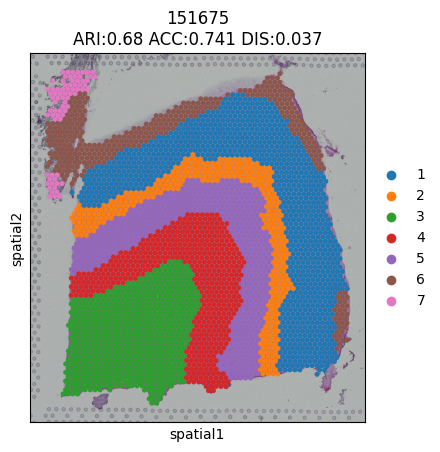

In [2]:
# Plotting spatial domain
sc.pl.spatial(
    adata,
    color=[tool],
    spot_size=140,
    title=dataset + '\nARI:' + str(round(ARI, 3)) + ' ACC:' + str(round(ACC, 3)) + ' DIS:' + str(round(DIS, 3)),
    show=True
)

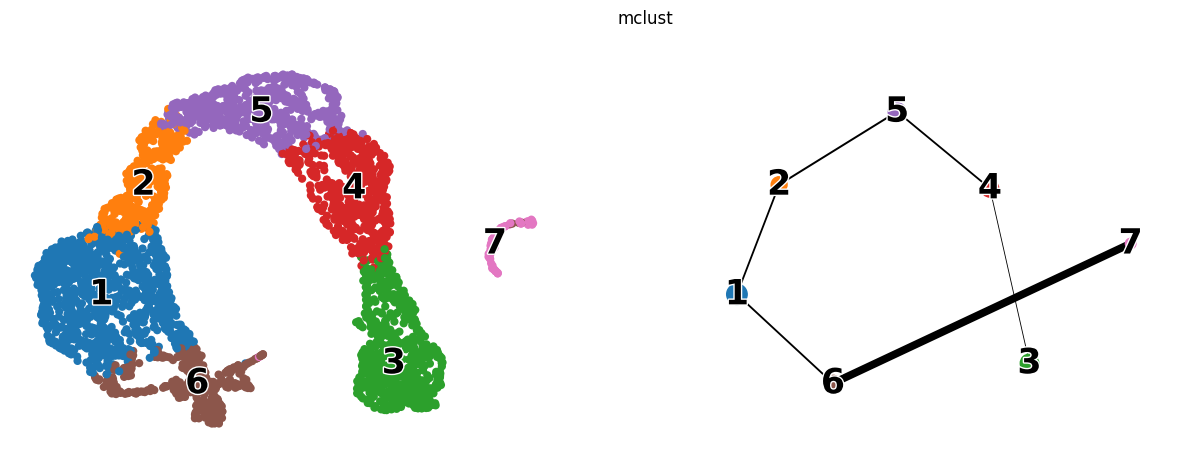

In [3]:
# Plotting UMAP & PAGA
sc.pp.neighbors(adata, n_neighbors=12, n_pcs=16, use_rep="latent")
sc.tl.umap(adata)
sc.tl.paga(adata, groups=tool)
sc.pl.paga_compare(adata, legend_fontsize=25, frameon=False, size=140, legend_fontoutline=2, show=True)